# **1. Perkenalan Dataset**


**Analisis dan Prediksi Customer Churn pada Perusahaan Telekomunikasi**

- **Sumber Dataset:** IBM Telco Customer Churn (Kaggle)
- **Deskripsi:** Dataset ini berisi data pelanggan dari sebuah perusahaan telekomunikasi yang menyediakan layanan telepon dan internet. Tujuannya adalah memprediksi apakah pelanggan akan mempertahankan layanan mereka atau pindah ke kompetitor (Churn).
- **Fitur Utama:** - `customerID`: ID unik pelanggan
  - `gender`, `SeniorCitizen`, `Partner`, `Dependents`: Demografi pelanggan
  - `tenure`: Jumlah bulan pelanggan telah berlangganan
  - `PhoneService`, `MultipleLines`, `InternetService`, dsb: Layanan yang digunakan
  - `Contract`, `PaperlessBilling`, `PaymentMethod`: Informasi akun/kontrak
  - `MonthlyCharges`, `TotalCharges`: Informasi finansial
  - `Churn`: Label target (Yes / No)
  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library dasar untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set pengaturan visualisasi agar rapi
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Tentukan path file dataset (sesuaikan jika nama filenya berbeda)
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Memuat dataset menggunakan pandas
df = pd.read_csv(file_path)

# Menampilkan ukuran dataset
print(f"Dataset berhasil dimuat! Ukuran data: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")

# Menampilkan 5 baris pertama untuk memahami strukturnya
df.head()

Dataset berhasil dimuat! Ukuran data: 7043 baris dan 21 kolom.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Memeriksa informasi tipe data dan missing values awal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1131/3485600627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


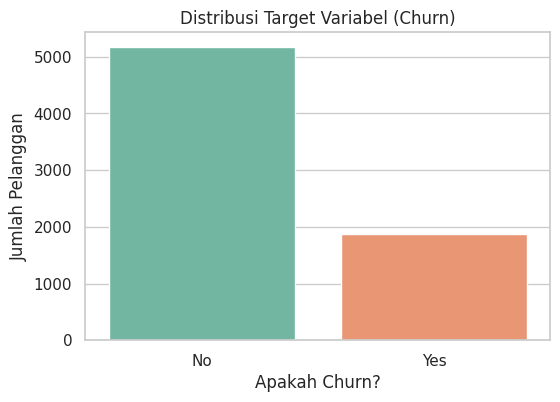

In [5]:
#Type yo# Menghitung jumlah dan persentase churn
print(df['Churn'].value_counts())
print("\nPersentase Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Target Variabel (Churn)')
plt.ylabel('Jumlah Pelanggan')
plt.xlabel('Apakah Churn?')
plt.show()

In [6]:
# Ringkasan statistik deskriptif untuk fitur numerik yang terdeteksi
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Menghitung spasi kosong pada kolom TotalCharges
missing_spaces = (df['TotalCharges'] == " ").sum()
print(f"Jumlah baris dengan spasi kosong pada TotalCharges: {missing_spaces}")

# Melihat contoh baris yang memiliki spasi kosong tersebut
df[df['TotalCharges'] == " "][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

Jumlah baris dengan spasi kosong pada TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# 1. Ubah spasi kosong menjadi NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# 2. Konversi tipe data menjadi float64
df['TotalCharges'] = df['TotalCharges'].astype(float)

# 3. Imputasi nilai NaN dengan median dari kolom TotalCharges
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

# Verifikasi apakah masih ada missing values
print(f"Jumlah missing values di TotalCharges setelah perbaikan: {df['TotalCharges'].isnull().sum()}")

Jumlah missing values di TotalCharges setelah perbaikan: 0


In [9]:
# Menghapus kolom customerID
df = df.drop(columns=['customerID'])
print(f"Ukuran dataset setelah kolom customerID dihapus: {df.shape}")

Ukuran dataset setelah kolom customerID dihapus: (7043, 20)


In [10]:
from sklearn.preprocessing import LabelEncoder

# 1. Encoding untuk variabel target (Churn: Yes -> 1, No -> 0)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# 2. Memisahkan fitur (X) dan target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 3. One-Hot Encoding untuk semua fitur kategorikal di X
X_encoded = pd.get_dummies(X, drop_first=True)

# Mengubah nilai Boolean (True/False) hasil get_dummies menjadi integer (1/0)
X_encoded = X_encoded.astype(int)

print(f"Ukuran fitur setelah encoding: {X_encoded.shape}")
X_encoded.head()

Ukuran fitur setelah encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [12]:
# Menggabungkan kembali fitur dan target yang sudah bersih
df_clean = X_encoded.copy()
df_clean['Churn'] = y

# Menyimpan menjadi file CSV bersih
df_clean.to_csv('Customer_Churn_Dataset_preprocessing.csv', index=False)
print("Dataset bersih berhasil disimpan dengan nama 'Customer_Churn_Datase_preprocessing.csv'!")

Dataset bersih berhasil disimpan dengan nama 'Customer_Churn_Datase_preprocessing.csv'!
